# Import Library & Set Globals

In [ ]:
# base
import os
import sys
import warnings
import logging
import pickle

# data manipulation
import pickle
import pandas as pd
import itables
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

# single cell
import scanpy as sc

itables.init_notebook_mode(connected=True)  # Use connected=False for offline use
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.ERROR)

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

from rpy2.robjects.conversion import localconverter

converter = get_converter()

# R_preload()
%load_ext rpy2.ipython

study = "Sarvari2021"

CORES = 10
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]

%matplotlib inline
mpl.rcdefaults()

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


# Access adata

In [ ]:
study_name = "Sarvari_download"

experiment_dir = Path("cellranger", study_name)
# for sample in pd.Series([file.split(".")[0] for file in os.listdir(DATADIR / experiment_dir)]).unique():
#     os.makedirs(DATADIR / experiment_dir / sample, exist_ok=True)
samples = [
    content
    for content in os.listdir(DATADIR / experiment_dir)
    if os.path.isdir(DATADIR / experiment_dir / content)
]

adatas = []
for sample in (pbar := tqdm(samples)):
    pbar.set_postfix_str(sample)
    folder = DATADIR / experiment_dir / sample
    adata = sc.AnnData(X=scipy.io.mmread(folder / f"{sample}.mtx.gz").toarray().T)
    adata.obs_names = list(
        pd.read_csv(folder / f"{sample}.barcodes.txt.gz", header=None)[0]
    )
    adata.var_names = list(
        pd.read_csv(folder / f"{sample}.genes.txt.gz", header=None)[0]
    )
    adata = adata[
        list(pd.read_csv(folder / f"{sample}.qc.txt.gz", header=None)[0])
    ].copy()

    adata.obs["Identifier"] = sample
    adata.obs["Sample"], adata.obs["Condition"], _ = np.array(
        adata.obs["Identifier"].str.split("_").to_list()
    ).T
    adata.layers["counts"] = adata.X.copy()
    adatas.append(adata)

[adata.shape[0] for adata in adatas]

In [235]:
for n, adata in enumerate(adatas):
    adata.obs["Identifier"] = samples[n]
    adata.obs["Sample"], adata.obs["Condition"], _ = np.array(
        adata.obs["Identifier"].str.split("_").to_list()
    ).T

# QC

### gene conversions

pybiomart

In [127]:
import pybiomart as pbm

# find dataset
server = pbm.Server(host="http://www.ensembl.org")
mart = server["ENSEMBL_MART_ENSEMBL"]
mart.list_datasets()

# find attributes of interest
dataset = pbm.Dataset(name="mmusculus_gene_ensembl", host="http://www.ensembl.org")
dataset.list_attributes()

# query attributes
conversions = dataset.query(attributes=["ensembl_gene_id", "external_gene_name"])
conversions.shape

# convert by join
ensembl_names = pd.DataFrame(list(set().union(*[set(ad.var_names) for ad in adatas])))
print(ensembl_names.shape)
converted_pbm = pd.merge(
    ensembl_names, conversions, left_on=0, right_on="Gene stable ID", how="left"
)
print(
    f"found: {(~converted_pbm["Gene stable ID"].isna()).sum()} || failed: {converted_pbm["Gene stable ID"].isna().sum()}"
)

# handle fails
converted_pbm["Gene name"].fillna(converted_pbm[0], inplace=True)

(30876, 1)
found: 29188 || failed: 1688


mygene

In [151]:
import mygene

mg = mygene.MyGeneInfo()
results = mg.querymany(
    list(ensembl_names[0]), species="mouse", fields="symbol", returnall=True
)

converted_mygene = pd.DataFrame(results["out"])
dups = np.sum([gene[1] - 1 for gene in results["dup"]])

print(
    f"found: {len(converted_mygene[converted_mygene['notfound'] != True])-dups} || duplicates: {dups} ({results['dup']}) || failed: {len(results['missing'])}"
)

found: 29186 || duplicates: 1 ([('ENSMUSG00000072694', 2)]) || failed: 1690


chose pybiomart

In [ ]:
for adata in adatas:
    adata.var_names = pd.Index(
        converted_pbm.set_index(0).loc[adata.var_names.tolist()]["Gene name"].values
    )

### qc

... storing 'Identifier' as categorical
... storing 'Sample' as categorical
... storing 'Condition' as categorical
... storing 'Identifier' as categorical
... storing 'Sample' as categorical
... storing 'Condition' as categorical
... storing 'Identifier' as categorical
... storing 'Sample' as categorical
... storing 'Condition' as categorical
... storing 'Identifier' as categorical
... storing 'Sample' as categorical
... storing 'Condition' as categorical
... storing 'Identifier' as categorical
... storing 'Sample' as categorical
... storing 'Condition' as categorical
... storing 'Identifier' as categorical
... storing 'Sample' as categorical
... storing 'Condition' as categorical


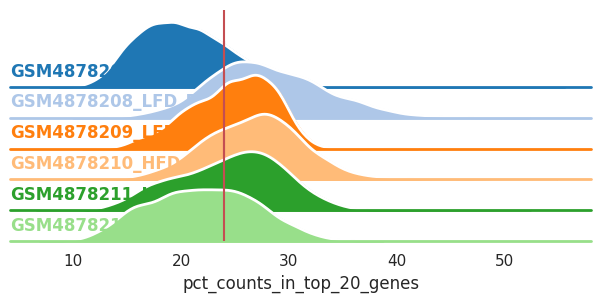

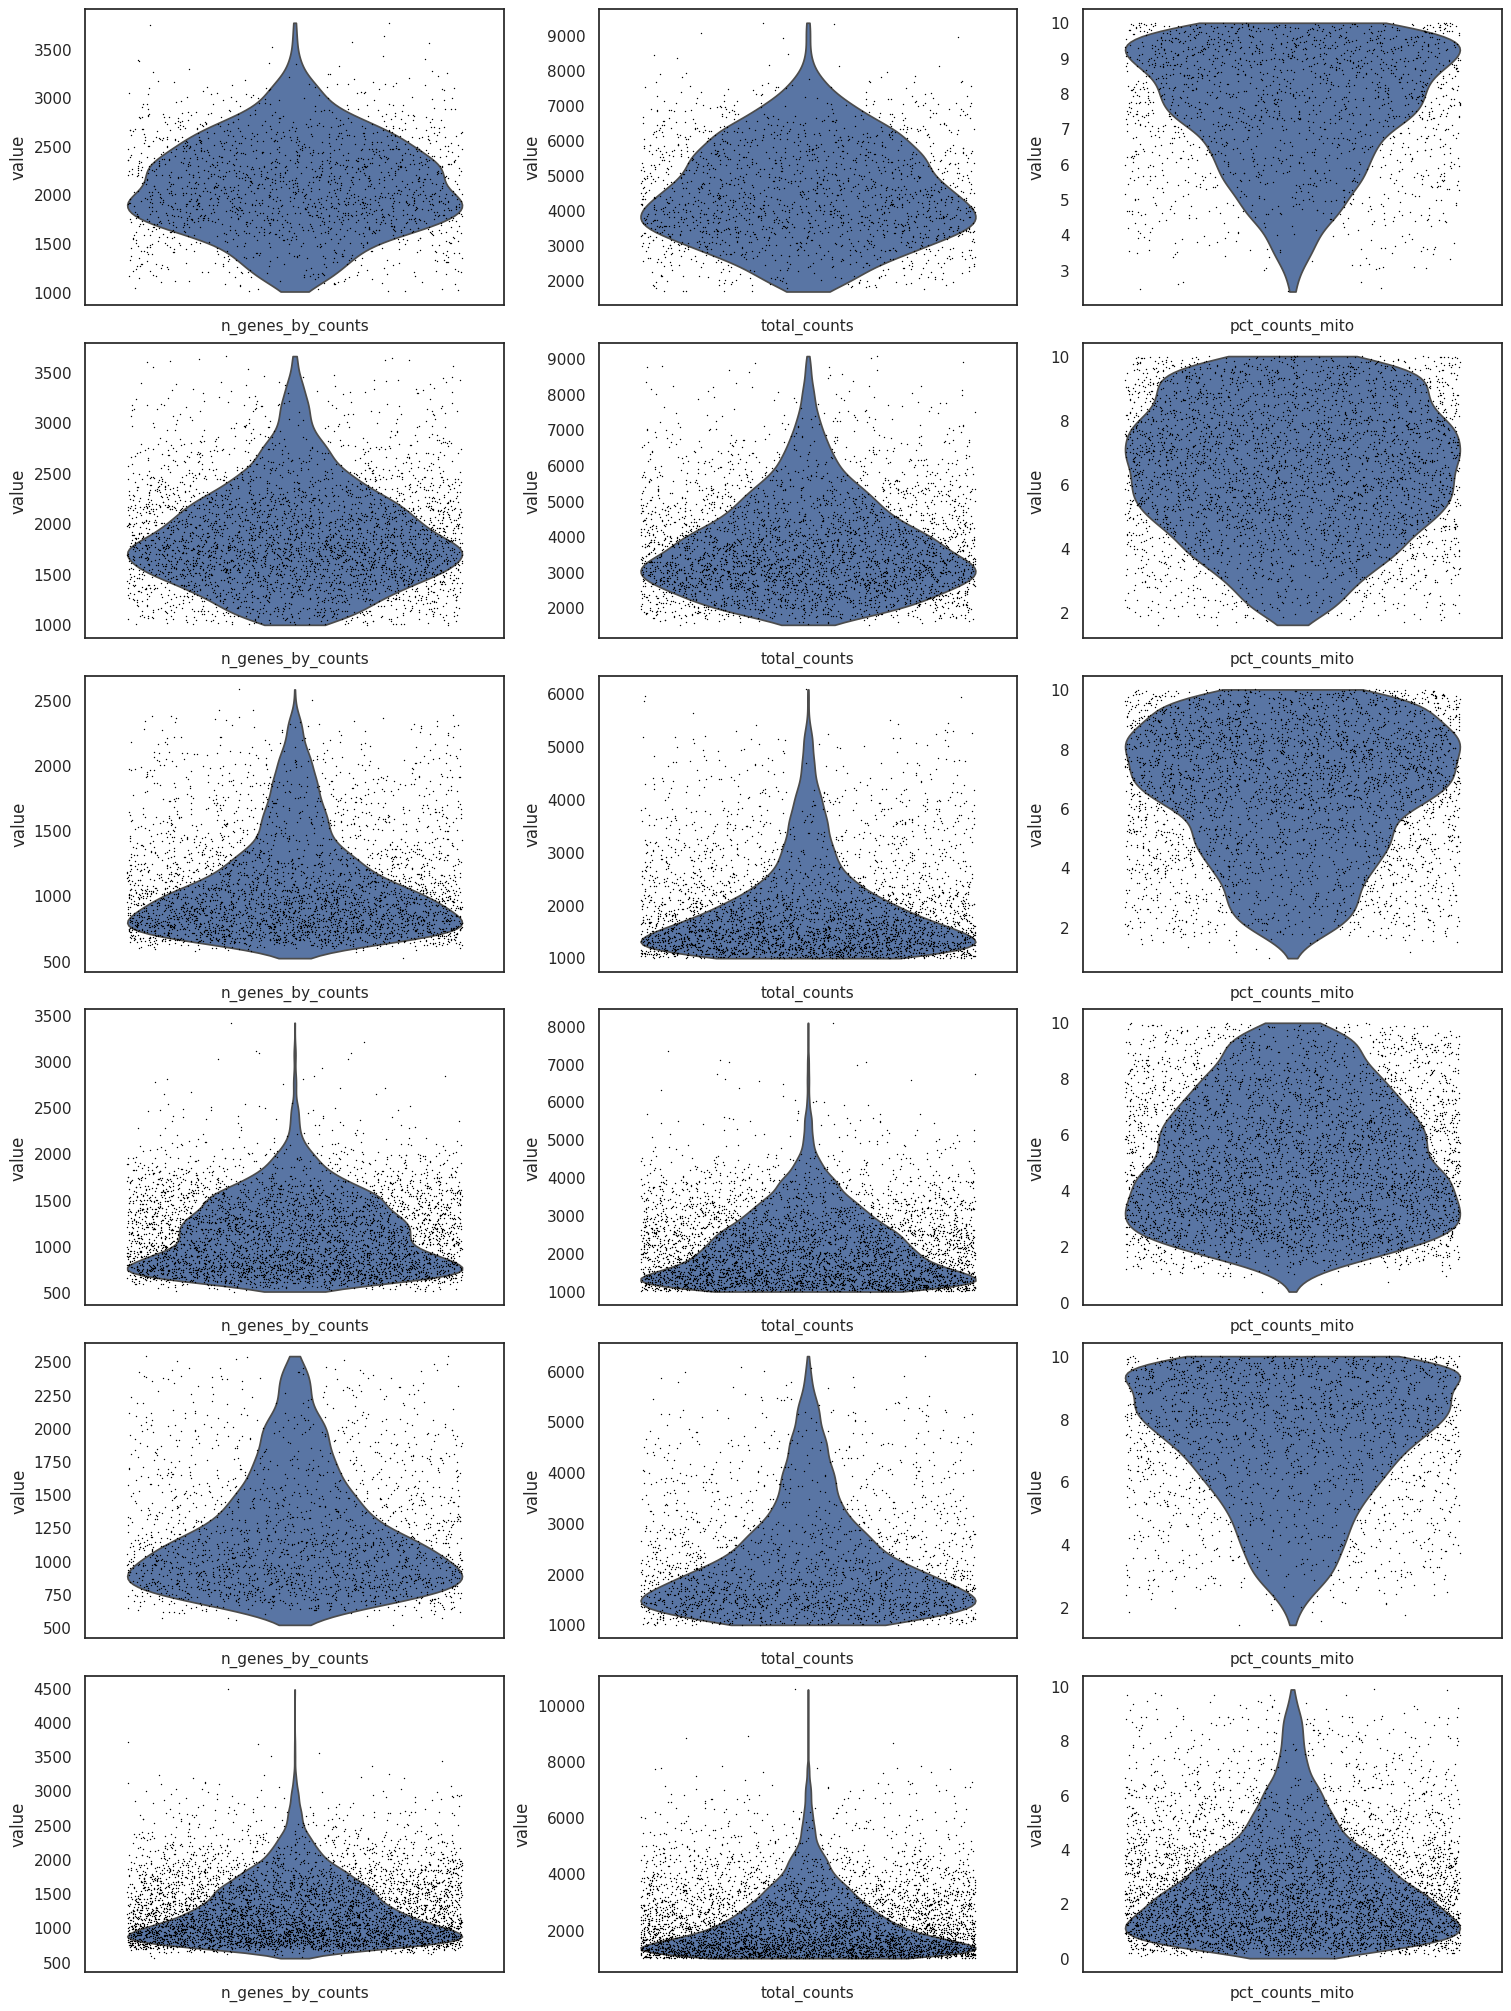

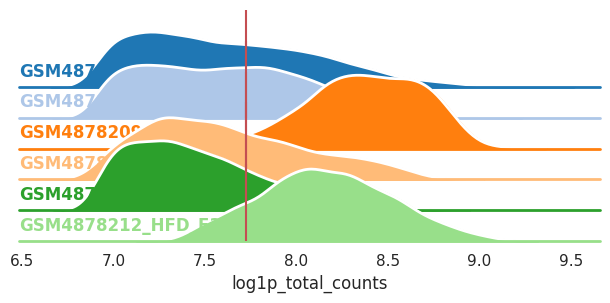

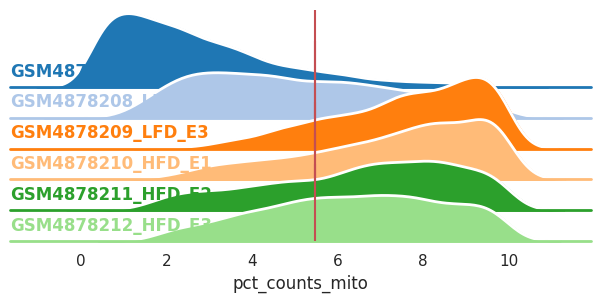

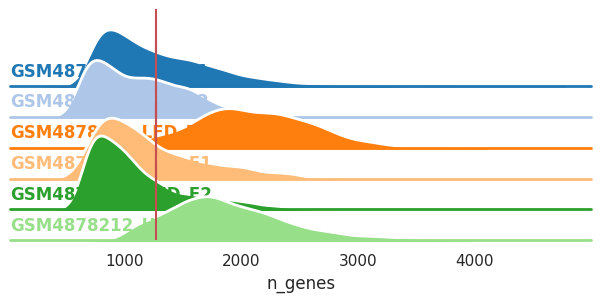

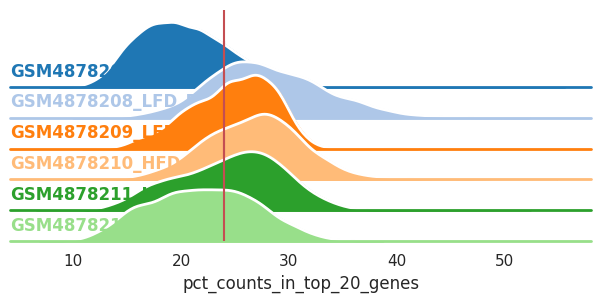

In [239]:
# adatas = [Filter_QC(dat, GenePerCell=500, CountPerCell=1000, CellPerGene=10, verbose=True) for dat in adatas]
# adatas = [Filter_GeneGroup(dat, verbose=True, perc_threshold=10) for dat in adatas]

groupby = "Identifier"
f, axs = plt.subplots(len(adatas), 3, figsize=(15, 20), layout="constrained")
for i in range(len(adatas)):
    for n, metric in enumerate(
        ["n_genes_by_counts", "total_counts", "pct_counts_mito"]
    ):
        sc.pl.violin(adatas[i], metric, jitter=0.4, ax=axs[i][n], show=False)
df = pd.concat([x.obs for x in adatas])
df = df.sort_values(groupby)

check_QCPlot(df, "log1p_total_counts", groupby)
check_QCPlot(df, "pct_counts_mito", groupby)
check_QCPlot(df, "n_genes", groupby)
check_QCPlot(df, "pct_counts_in_top_20_genes", groupby)

# Doublets

In [9]:
print("methods available:", DOUBLETMETHODS)
compare_doublets = True
method = "scDblFinder"
method_short = "scDF"

if compare_doublets is True:
    for method in DOUBLETMETHODS:
        adatas = [Filter_Doublet(dat, method, remove=False) for dat in tqdm(adatas)]

else:
    print(f"Doublet method selected: {method}\n")
    adatas = [Filter_Doublet(dat, method, remove=True) for dat in adatas]
    for dat in adatas:
        print(len(dat), dat.uns["doublets_removed"])

adatas

methods available: ['scDblFinder', 'DoubletFinder', 'doubletdetection', 'scrublet']


2025-10-31 14:41:01 | [WARNING] R callback write-console: Creating ~3177 artificial doublets...
  
2025-10-31 14:41:07 | [WARNING] R callback write-console: Dimensional reduction
  
2025-10-31 14:41:09 | [WARNING] R callback write-console: Evaluating kNN...
  
2025-10-31 14:41:12 | [WARNING] R callback write-console: Training model...
  
2025-10-31 14:41:12 | [WARNING] R callback write-console: iter=0, 416 cells excluded from training.
  
2025-10-31 14:41:18 | [WARNING] R callback write-console: iter=1, 338 cells excluded from training.
  
2025-10-31 14:41:23 | [WARNING] R callback write-console: iter=2, 300 cells excluded from training.
  
2025-10-31 14:41:27 | [WARNING] R callback write-console: Threshold found:0.461
  
2025-10-31 14:41:27 | [WARNING] R callback write-console: 101 (2.5%) doublets called
  


0       singlet
1       singlet
2       singlet
3       singlet
4       singlet
         ...   
3966    singlet
3967    singlet
3968    singlet
3969    singlet
3970    singlet
Length: 3971, dtype: object


2025-10-31 14:43:20 | [WARNING] R callback write-console: Creating ~3610 artificial doublets...
  
2025-10-31 14:43:25 | [WARNING] R callback write-console: Dimensional reduction
  
2025-10-31 14:43:28 | [WARNING] R callback write-console: Evaluating kNN...
  
2025-10-31 14:43:31 | [WARNING] R callback write-console: Training model...
  
2025-10-31 14:43:31 | [WARNING] R callback write-console: iter=0, 409 cells excluded from training.
  
2025-10-31 14:43:37 | [WARNING] R callback write-console: iter=1, 328 cells excluded from training.
  
2025-10-31 14:43:45 | [WARNING] R callback write-console: iter=2, 247 cells excluded from training.
  
2025-10-31 14:43:50 | [WARNING] R callback write-console: Threshold found:0.322
  
2025-10-31 14:43:50 | [WARNING] R callback write-console: 97 (2.1%) doublets called
  


0       singlet
1       singlet
2       singlet
3       singlet
4       singlet
         ...   
4507    singlet
4508    singlet
4509    singlet
4510    singlet
4511    singlet
Length: 4512, dtype: object


...

[1] "Scaling data..."


2025-10-31 15:18:22 | [WARNING] R callback write-console: Centering and scaling data matrix
  
  |                                                                              
  |                                                                      |   0%  
  |                                                                              
  |===================================                                   |  50%  
  |                                                                              
  |======================================================================| 100%  
2025-10-31 15:18:23 | [WARNING] R callback write-console: 
  


[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Computing pANN..."
[1] "Classifying doublets.."


2025-10-31 15:18:29 | [WARNING] R callback write-console: In addition:   
2025-10-31 15:18:29 | [WARNING] R callback write-console: Warning message:
  
2025-10-31 15:18:29 | [WARNING] R callback write-console: Key ‘originalexp_’ taken, using ‘rna_’ instead 
  
100%|██████████| 10/10 [00:39<00:00,  3.95s/it]


[AnnData object with n_obs × n_vars = 3971 × 27668
     obs: 'Identifier', 'Sample', 'Condition', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'predicted_doublet-scDblFinder', 'doublet_score-scDblFinder', 'predicted_doublet-DoubletFinder', 'doublet_score-DoubletFinder', 'predicted_doublet-doubletdetection', 'doublet_score-doubletdetection', 'predicted_doublet-scrublet', 'doublet_score-scrublet'
     var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
     uns: 'methods', 'doublet_remover', 'scrublet'
     layers: 'counts',
 AnnData object with n_obs × n_vars = 4512 × 27129
     obs: 'Identifier', 'Sample', 'Condition', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'predicted_doublet-scDblFinder', 'doublet_score-scDblFind

In [32]:
# save
annotation = "hasDoublets"
savedir = os.path.join(DATADIR, "processed", "single cell", study)
os.makedirs(savedir, exist_ok=True)
with open(os.path.join(savedir, f"{annotation}.pickle"), "wb") as handle:
    pickle.dump(adatas, handle)

Pre-Doublet Integration

In [43]:
# load adata
annotation = "hasDoublets"
savedir = os.path.join(DATADIR, "processed", "single cell", study)
with open(
    os.path.join(savedir, f"{annotation}.pickle"),
    "rb",
) as handle:
    adatas = pickle.load(handle)

Saving normalized counts in layer 'normalized'.
Finding HVGs...
Integrating by Column Identifier: ['GSM4878209_LFD_E3', 'GSM4878212_HFD_E3', 'GSM4878211_HFD_E2', 'GSM4878208_LFD_E2', 'GSM4878210_HFD_E1', 'GSM4878207_LFD_E1']
Categories (6, object): ['GSM4878207_LFD_E1', 'GSM4878208_LFD_E2', 'GSM4878209_LFD_E3', 'GSM4878210_HFD_E1', 'GSM4878211_HFD_E2', 'GSM4878212_HFD_E3']


2025-11-03 13:44:14,717 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-03 13:44:14 | [INFO] Computing initial centroids with sklearn.KMeans...
2025-11-03 13:44:19,242 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-03 13:44:19 | [INFO] sklearn.KMeans initialization complete.
2025-11-03 13:44:19,419 - harmonypy - INFO - Iteration 1 of 50
2025-11-03 13:44:19 | [INFO] Iteration 1 of 50
2025-11-03 13:44:32,328 - harmonypy - INFO - Iteration 2 of 50
2025-11-03 13:44:32 | [INFO] Iteration 2 of 50
2025-11-03 13:44:45,305 - harmonypy - INFO - Iteration 3 of 50
2025-11-03 13:44:45 | [INFO] Iteration 3 of 50
2025-11-03 13:44:58,507 - harmonypy - INFO - Iteration 4 of 50
2025-11-03 13:44:58 | [INFO] Iteration 4 of 50
2025-11-03 13:45:11,852 - harmonypy - INFO - Iteration 5 of 50
2025-11-03 13:45:11 | [INFO] Iteration 5 of 50
2025-11-03 13:45:24,504 - harmonypy - INFO - Iteration 6 of 50
2025-11-03 13:45:24 | [INFO] Iteration 6 of 50
2025-11-03

Starting UMAP...
Starting LocalMAP...


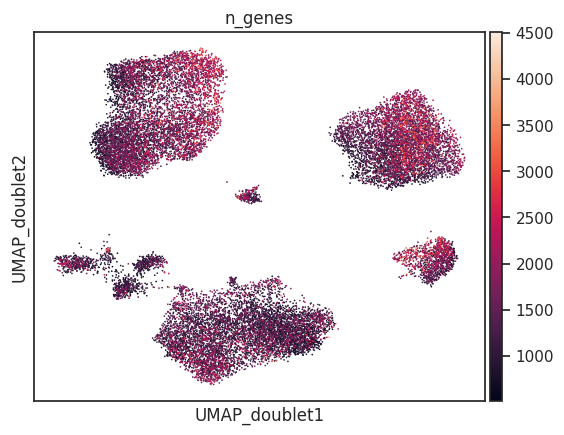

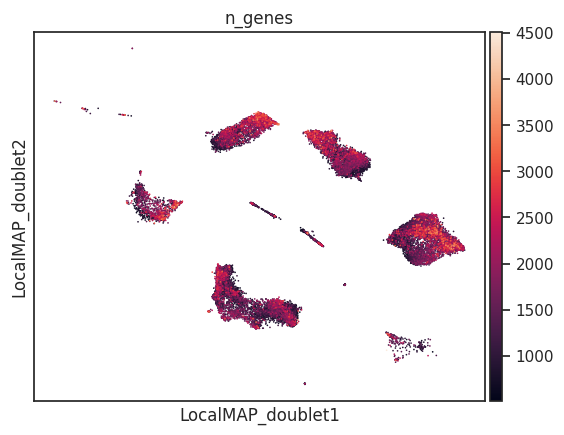

AnnData object with n_obs × n_vars = 20800 × 19218
    obs: 'Identifier', 'Sample', 'Condition', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'predicted_doublet-scDblFinder', 'doublet_score-scDblFinder', 'predicted_doublet-DoubletFinder', 'doublet_score-DoubletFinder', 'predicted_doublet-doubletdetection', 'doublet_score-doubletdetection', 'predicted_doublet-scrublet', 'doublet_score-scrublet', 'pct_counts_mito'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'methods', 'log1p', 'hvg', 'pca', 'neighbors', 'UMAP_doublet'
    obsm: 'X_pca', 'integrated', 'UMAP_doublet', 'LocalMAP_doublet'
    varm: 'PCs'
    layers: 'counts', 'normalized'
    obsp: 'distances', 'connectivities'

In [264]:
batch_column = "Identifier"
hvg_kind = "seurat_v3"
int_kind = "harmony"

# merge
adata = sc.concat(adatas, join="outer")
adata.X = np.nan_to_num(adata.X)
adata.layers["counts"] = adata.X.copy()
adata.raw = adata.copy()

# process & integrate
adata = Normalize(adata, kind="log1p", batch_column=batch_column)
adata = FindVariableGenes(adata, kind=hvg_kind, batch_column=batch_column)
adata = Integrate(adata, kind=int_kind, batch_column=batch_column, use_var_genes=True)
adata = Visualize(adata, key="_doublet")
sc.pl.embedding(adata, basis="UMAP_doublet", color="n_genes")
sc.pl.embedding(adata, basis="LocalMAP_doublet", color="n_genes")

adata

Save/Load

In [ ]:
# save
annotation = "hasDoublets-integrated"
savedir = os.path.join(DATADIR, "processed", "single cell", study)
os.makedirs(savedir, exist_ok=True)
adata.write(os.path.join(savedir, f"{annotation}.h5ad"))

In [ ]:
# load
annotation = "hasDoublets-integrated"
savedir = os.path.join(DATADIR, "processed", "single cell", study)
adata = sc.read_h5ad(os.path.join(savedir, f"{annotation}.h5ad"))

Explore doublets

<Axes: title={'center': 'Condition'}, xlabel='LocalMAP_doublet1', ylabel='LocalMAP_doublet2'>

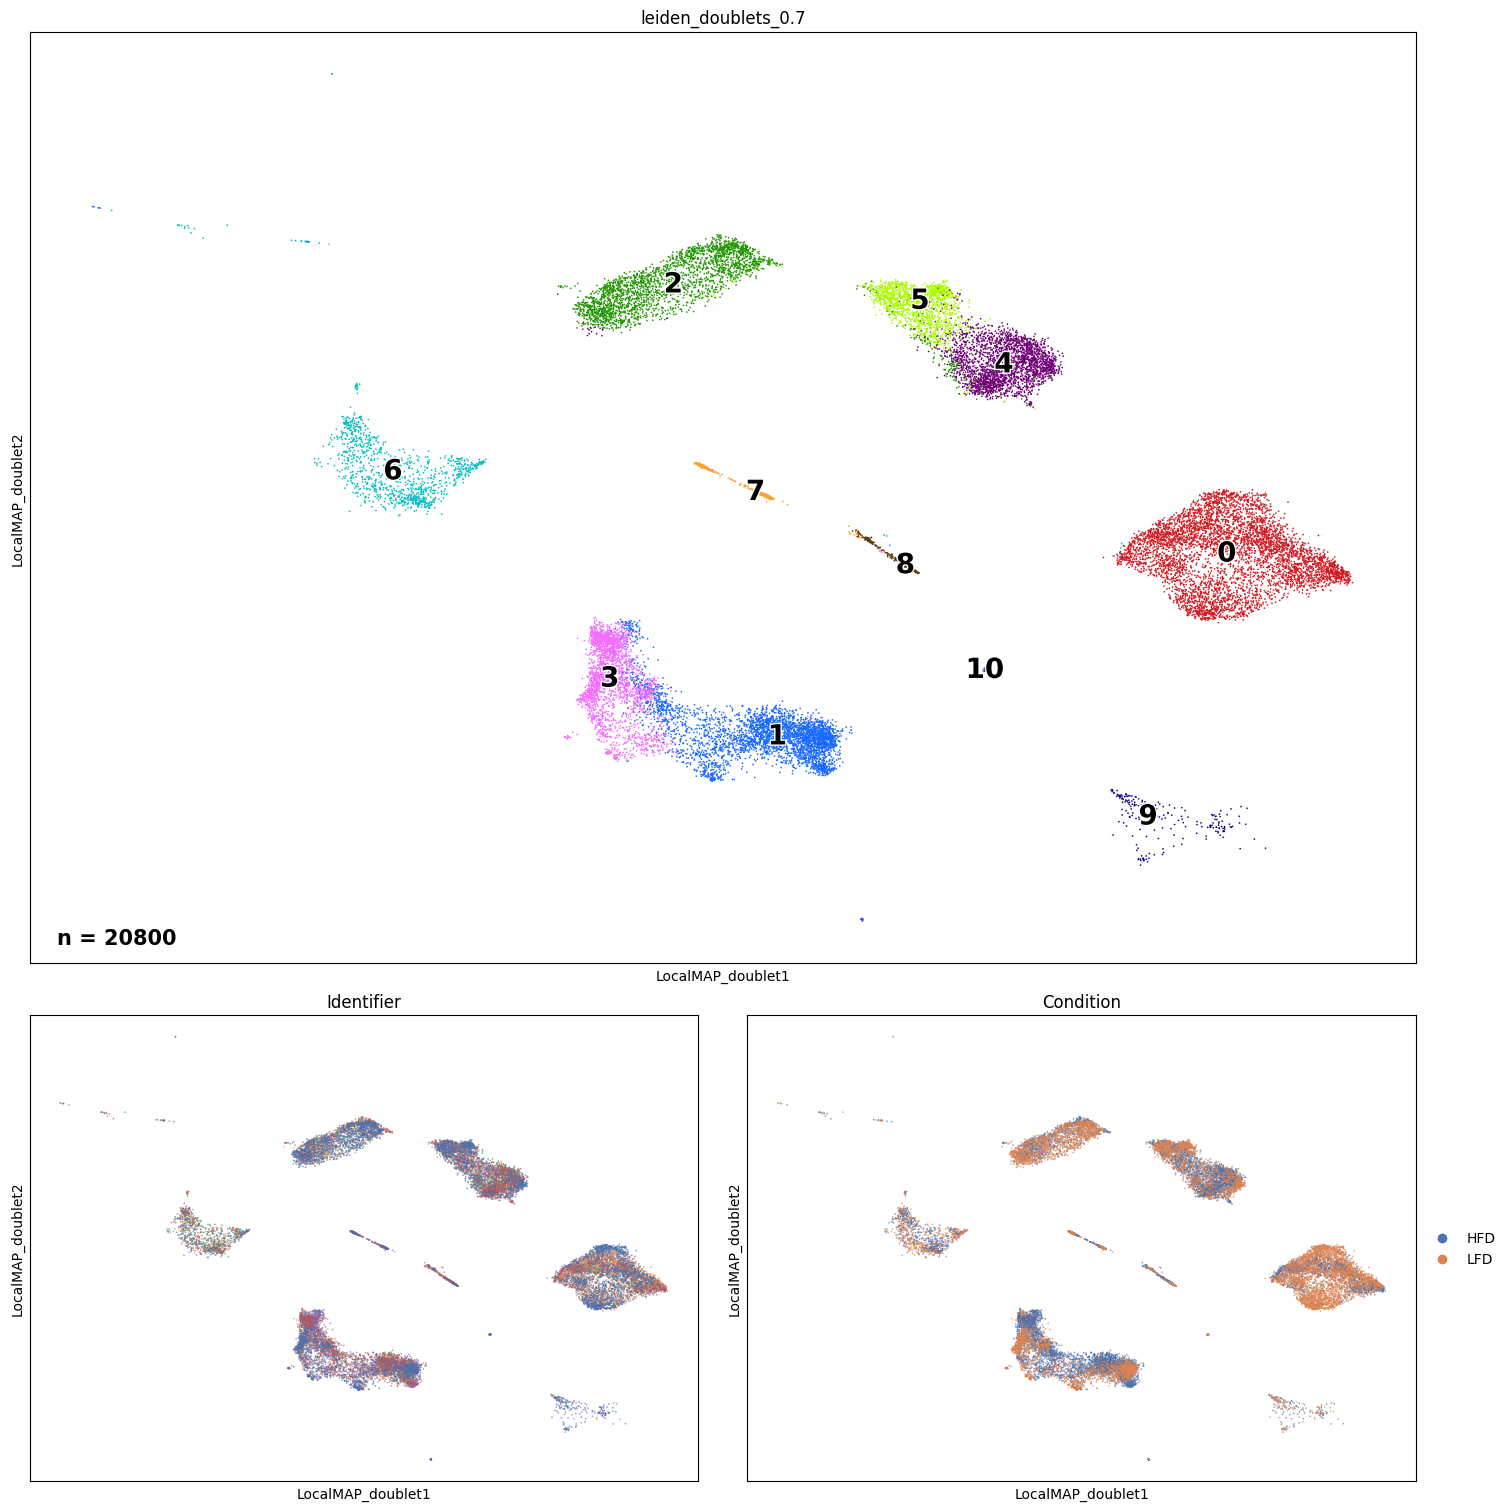

In [274]:
key = "leiden_doublets"
resolution = 0.7
cluster_key = f"{key}_{resolution:.1f}"
runCluster = False
embedding = "LocalMAP_doublet"

# leiden clustering
if runCluster is True:
    Cluster(adata, key, [0.5, 0.7, 1.0])

# figure prept
cluster_c = color_gen(adata.obs[cluster_key])
f = plt.figure(figsize=(15, 15), layout="constrained")

axs = f.subplots(3, 2)
gs = axs[0, 0].get_gridspec()
for rs in axs[:]:
    for ax in rs[:]:
        ax.remove()

# Large LocalMAP plot
ax = f.add_subplot(gs[:2, :])
sc.pl.embedding(
    adata,
    basis=embedding,
    color=cluster_key,
    ax=ax,
    show=False,
    legend_loc="on data",
    legend_fontoutline=2,
    legend_fontsize=20,
    palette=cluster_c.to_list(),
)
ax.annotate(
    f"n = {adata.shape[0]}",
    (0.02, 0.02),
    fontweight="bold",
    fontsize=15,
    xycoords="axes fraction",
)

ax = f.add_subplot(gs[2, 0])
sc.pl.embedding(
    adata,
    basis=embedding,
    color=["Identifier"],
    ax=ax,
    show=False,
    alpha=0.7,
    legend_loc="none",
)
ax = f.add_subplot(gs[2, 1])
sc.pl.embedding(
    adata, basis=embedding, color=["Condition"], ax=ax, show=False, alpha=0.7
)

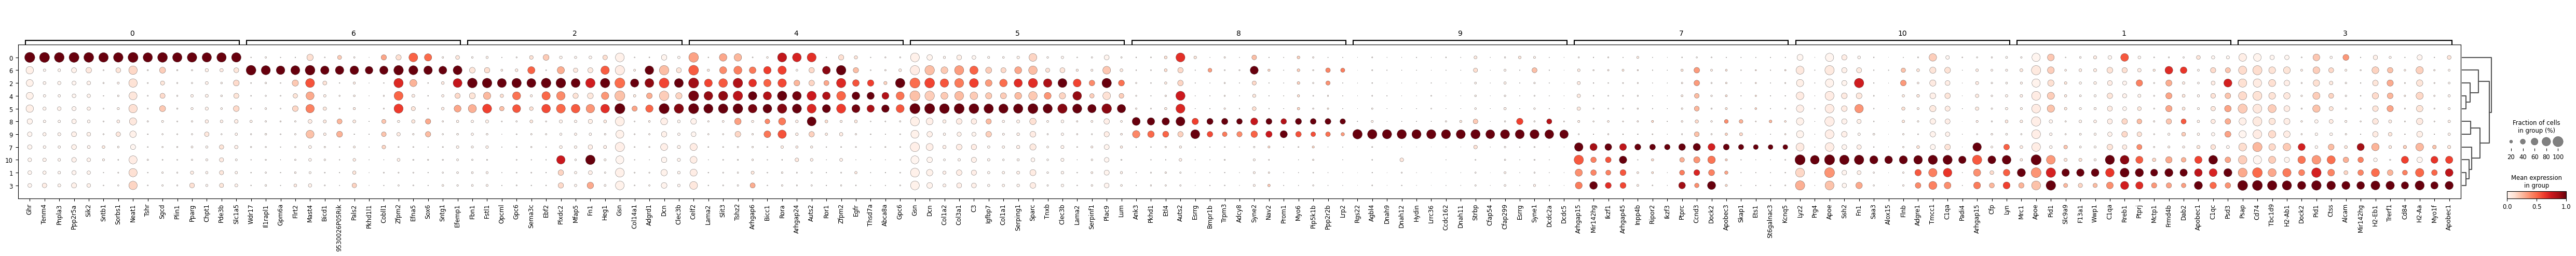

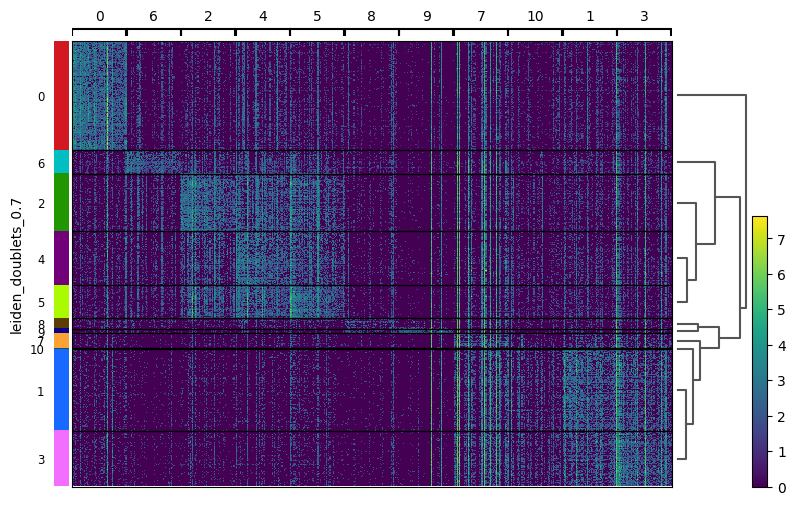

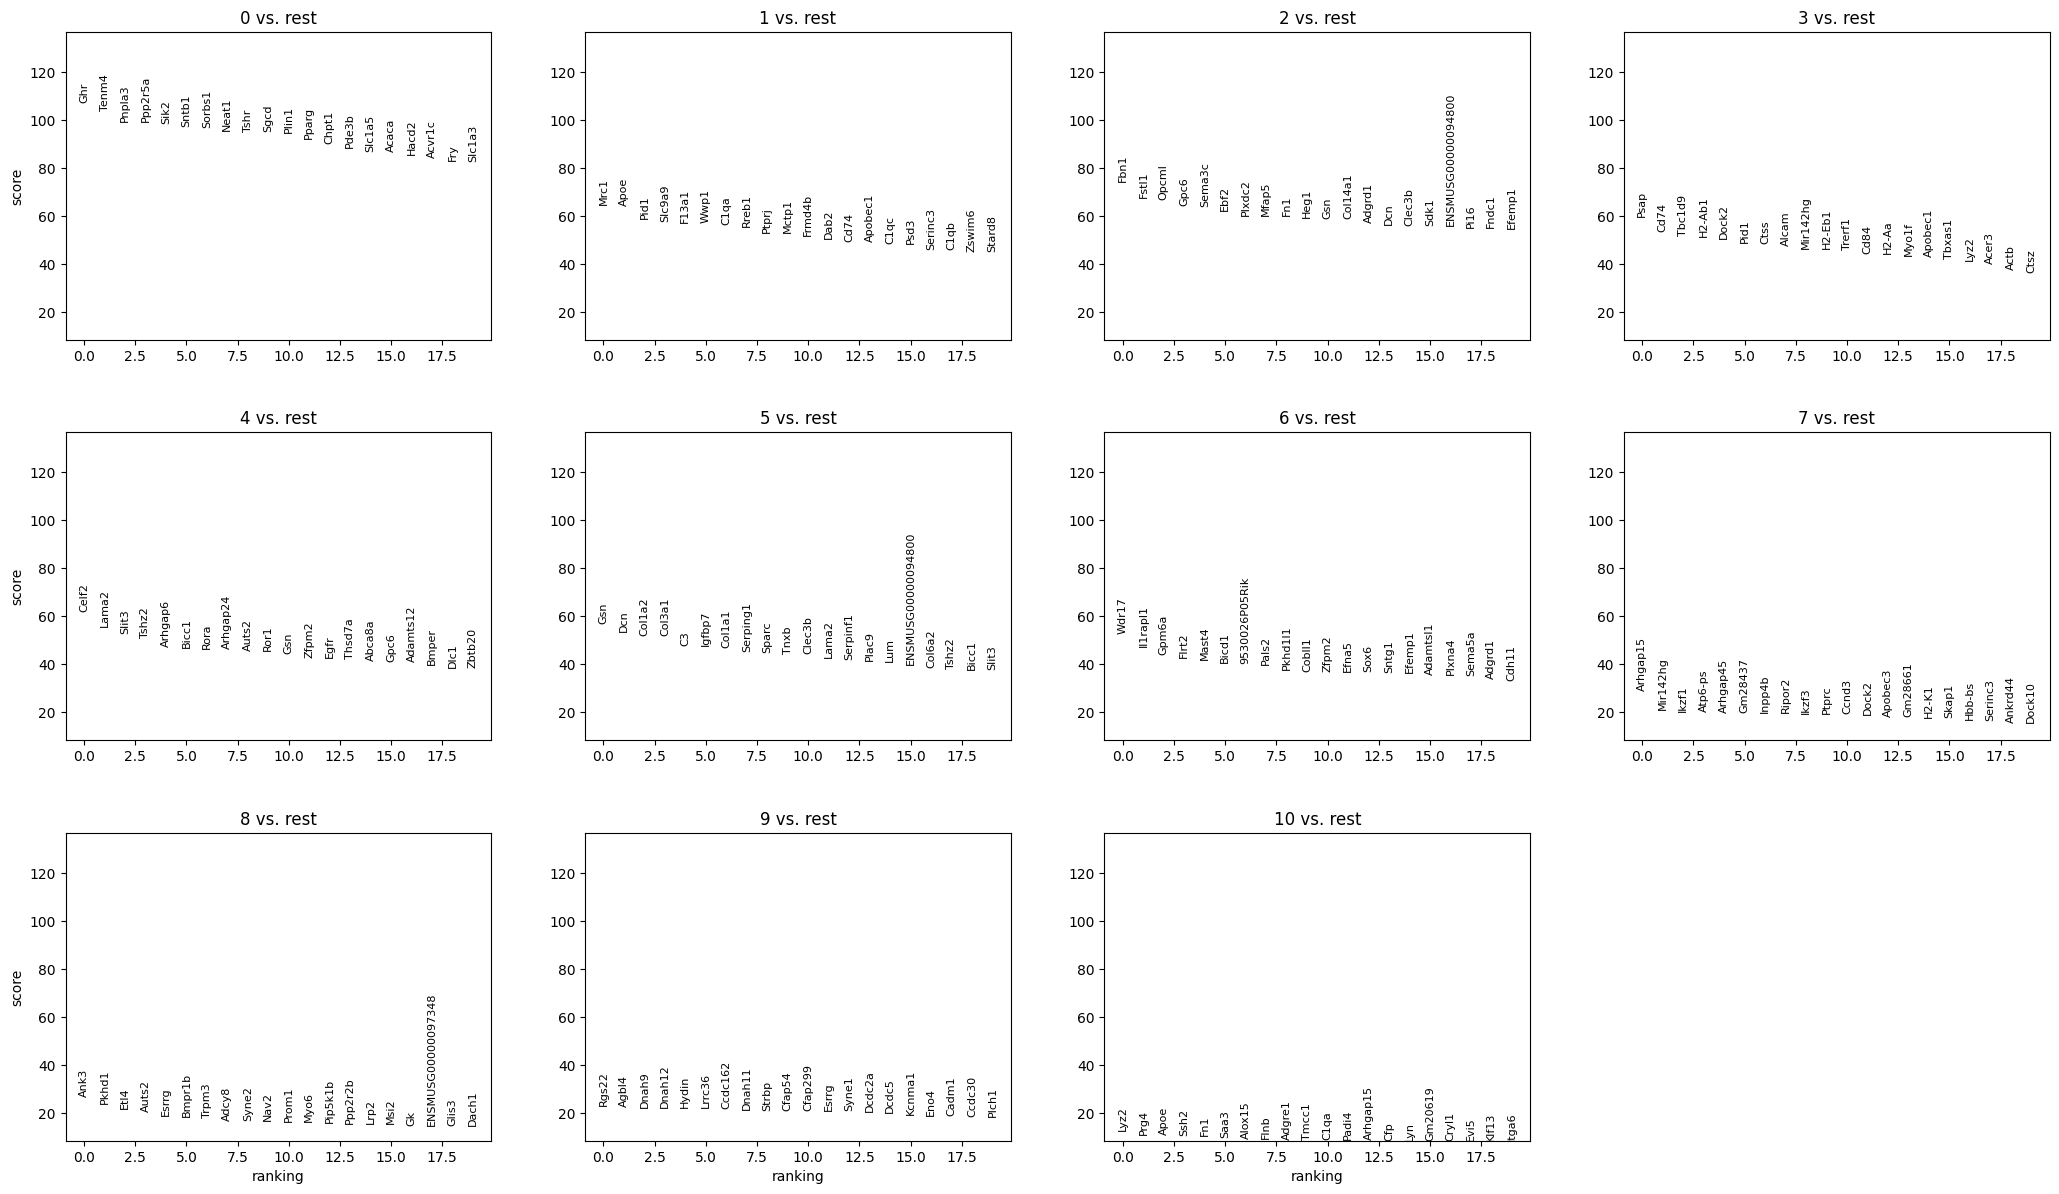

In [270]:
key = "leiden_doublets"
resolution = 0.7
cluster_key = f"{key}_{resolution:.1f}"
de_key = "DEGs"
runDEGs = False

if runDEGs is True:
    sc.tl.rank_genes_groups(
        adata,
        groupby=cluster_key,
        key_added=de_key,
        use_raw=False,
        layer="normalized",
        method="wilcoxon",
    )

sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby=cluster_key,
    key=de_key,
    standard_scale="var",
    n_genes=15,
    min_logfoldchange=2,
)

sc.pl.rank_genes_groups_heatmap(
    adata, key=de_key, groupby=cluster_key, layer="normalized", n_genes=50
)

sc.pl.rank_genes_groups(adata, adata.obs[cluster_key].cat.categories, key=de_key)

predicted_doublet-scDblFinder          927
predicted_doublet-DoubletFinder       1617
predicted_doublet-doubletdetection    1762
predicted_doublet-scrublet              58
dtype: int64


458

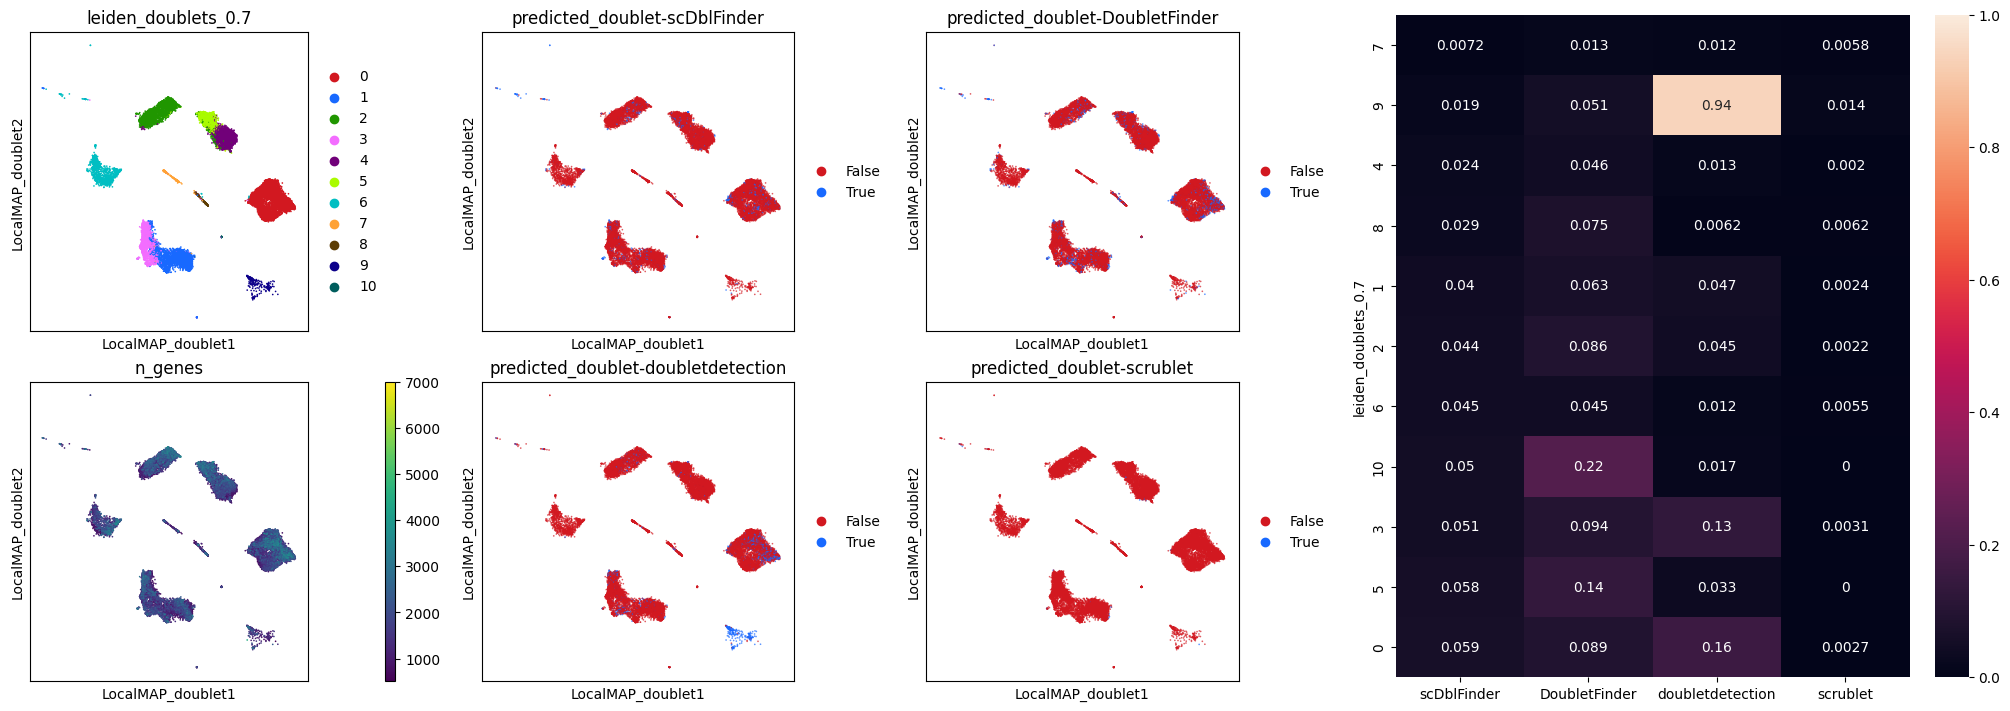

In [ ]:
key = "leiden_doublets"
resolution = 0.7
cluster_key = f"{key}_{resolution:.1f}"

check_doublets(adata, "LocalMAP_doublet", cluster_key)
print(adata.obs[[f"predicted_doublet-{m}" for m in DOUBLETMETHODS]].sum(axis=0))
multi_doublet = adata.obs[[f"predicted_doublet-{m}" for m in DOUBLETMETHODS]].sum(
    axis=1
)

458


Text(0.02, 0.02, 'n = 20800')

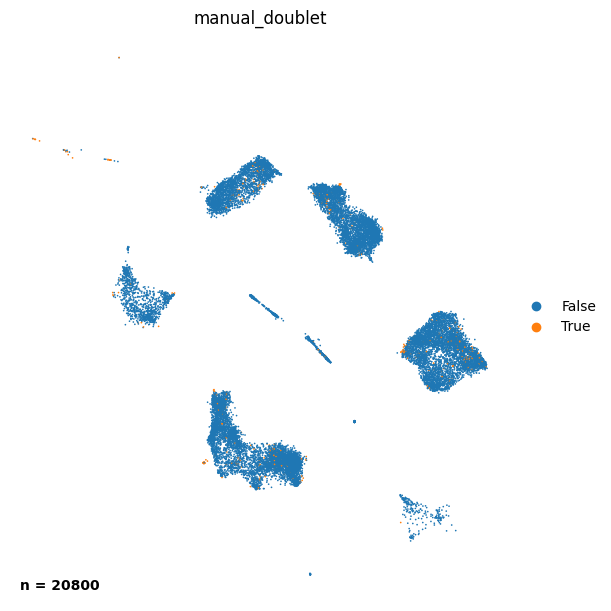

In [ ]:
# doublet_clusters = pd.Series([11, 15, 16, 23, 21, 26, 14, 28]).astype(str)
adata.obs["manual_doublet"] = multi_doublet
print(adata.obs["manual_doublet"].sum())

f, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))
sc.pl.embedding(
    adata, basis=embedding, color="manual_doublet", frameon=False, ax=ax, show=False
)
ax.annotate(
    f"n = {adata.shape[0]}",
    (0.02, 0.02),
    fontweight="bold",
    fontsize=10,
    xycoords="axes fraction",
)

In [276]:
# save
annotation = "doublet_cleaned"
savedir = os.path.join(DATADIR, "processed", "single cell", study)
os.makedirs(savedir, exist_ok=True)
adata[~adata.obs["manual_doublet"]].write(os.path.join(savedir, f"{annotation}.h5ad"))

# Integration

In [ ]:
# load
annotation = "doublet_cleaned"
savedir = os.path.join(DATADIR, "processed", "single cell", study)
adata = sc.read_h5ad(os.path.join(savedir, f"{annotation}.h5ad"))